# Brain–behaviour correlation: common prior shift vs. shift in neural coding

**Not in the paper** — additional analysis, prepared in response to a reviewer request.

The correlation between the behavioural prior shift and the neural coding shift
(`E_dif`) was in the earlier figure drafts (`archive/paper_fig_1.ipynb`,
`archive/paper_fig_2.ipynb`) but was computed on the **risky prior of PMC model 1**.
The model reported in the paper is **model 5**, where risky and safe priors shift
*together* (`prior_mu ~ 0 + session*group`). This notebook redoes the analysis on
that common prior shift, and compares it with the old model-1 version.

> **On the model label:** `build_model` in `behavior/utils.py` defines model `9` as
> `risky_prior_mu ~ session*group*AUC` — cortisol AUC as a regressor on the *risky*
> prior only, not a common prior shift — and no `model-9_trace.netcdf` has ever been
> fit. The common-prior model is **`5`**, which is also the paper model, so that is
> what is used here. Set `model_label` below to change it.

Run with the **`behav_fit`** environment.

In [1]:
import os.path as op
import numpy as np
import pandas as pd
import arviz as az
import pingouin
import matplotlib.pyplot as plt
import seaborn as sns

# on the department share (assemble it first, see ../DATA_ON_SHARE.md):
# bids_folder = '/Volumes/g_econ_department$/projects/2022/renkert_dehollander_aydogan_ruff_stressrisk/data/ds-stressrisk_remaining'
bids_folder = '/Users/mrenke/data/ds-stressrisk'
plot_folder_path = '/Users/mrenke/Desktop/StressRisk/figures/plots/paper'

model_label = '5'   # PMC model with a common prior shift (the paper model)

sns.set_theme('paper', 'white', font='helvetica', font_scale=1.5, palette='tab10')

/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


## 1. Behavioural measure: per-subject common prior shift (session 2 − session 1)

Model 5 specifies `prior_mu` as `0 + session*group`, i.e. **no intercept**, so the
per-subject posterior of `prior_mu` has the regressors `session`, `group`,
`session:group` and the session shift is

| | shift (ses2 − ses1) |
| --- | --- |
| control (group 0) | `session` |
| stress (group 1) | `session + session:group` |

Same derivation as `behavior/nlc-model_comp.ipynb`; verified below against the stored
`interim_sum_data/subwise_change_prior_model-5.csv`.

In [2]:
group_mapping = pd.read_csv(op.join(bids_folder, 'group_assignmentList.csv'))[['subject', 'group']].set_index('subject')['group']

idata = az.from_netcdf(op.join(bids_folder, 'derivatives', 'cogmodels', f'model-{model_label}_trace.netcdf'))

post = idata.posterior['prior_mu'].to_dataframe()
post = post.join(group_mapping, on='subject').set_index('group', append=True)
R = 'prior_mu_regressors'
print('regressors:', list(idata.posterior['prior_mu'].coords[R].values))

shift_g0 = post.xs('session', 0, R).xs(0, 0, 'group')
shift_g1 = post.xs('session', 0, R).xs(1, 0, 'group') + post.xs('session:group', 0, R).xs(1, 0, 'group')

shift = pd.concat([shift_g0, shift_g1]).groupby('subject')['prior_mu'].agg(['mean', 'std'])
shift.columns = ['prior_shift', 'prior_shift_sd']
print(f'n subjects: {len(shift)}')
shift.head()

regressors: ['session', 'group', 'session:group']
n subjects: 50


,prior_shift,prior_shift_sd
subject,,
1,-0.009912,0.158977
2,0.058431,0.323770
3,0.185066,0.236798
4,0.433309,0.258464
5,-0.053908,0.169397


In [3]:
# sanity check against the version saved in 2023
old = pd.read_csv(op.join(bids_folder, 'interim_sum_data', f'subwise_change_prior_model-{model_label}.csv')).set_index('subject')['prior_mu']
chk = shift[['prior_shift']].join(old.rename('stored'), how='inner').dropna()
print(f'n={len(chk)}, r={np.corrcoef(chk["prior_shift"], chk["stored"])[0,1]:.6f}, max|diff|={np.abs(chk["prior_shift"]-chk["stored"]).max():.2g}')

n=50, r=1.000000, max|diff|=9e-17


## 2. Neural measure: shift in neural coding `E_dif`

Identical to `paperFinal_allMainPlotsStatistics_.ipynb`: session-2 trials decoded
with the **across-session** decoder (encode ses-1 → decode ses-2) minus the same
trials decoded **within** session 2.

In [4]:
Es_within = pd.read_csv(op.join(bids_folder, 'interim_sum_data', 'within_ses_decodedE.csv'))
Es_across = pd.read_csv(op.join(bids_folder, 'interim_sum_data', 'across_ses_decodedE.csv'))

Es_within = Es_within.set_index(['subject', 'trial_nr', 'session']).rename(mapper={'E':'E_w', 'sd':'sd_w'}, axis=1).xs(2, 0, 'session')
Es_across = Es_across.set_index(['subject', 'trial_nr']).rename(mapper={'E':'E_a', 'sd':'sd_a'}, axis=1)

Es = Es_within.join(Es_across)
Es['E_dif'] = Es['E_a'] - Es['E_w']

E = Es.groupby('subject')[['E_dif']].mean()
print(f'n subjects: {len(E)}')

df = shift.join(E, how='inner').join(group_mapping).dropna(subset=['prior_shift', 'E_dif'])
print(f'n in correlation: {len(df)}   (sub-01 has no ses-2 decoding)')
df.head()

n subjects: 49
n in correlation: 49   (sub-01 has no ses-2 decoding)


,prior_shift,prior_shift_sd,E_dif,group
subject,,,,
2,0.058431,0.323770,0.010657,0
3,0.185066,0.236798,0.075062,1
4,0.433309,0.258464,0.143165,1
5,-0.053908,0.169397,-0.012330,0
9,-0.301888,0.164163,0.041127,0


## 3. Correlation

Reported with several estimators; `shepherd` (robust, as used in the earlier drafts)
is the one the old figure showed.

In [5]:
for method in ['pearson', 'spearman', 'bicor', 'shepherd', 'percbend']:
    c = pingouin.corr(df['prior_shift'], df['E_dif'], method=method)
    extra = f", outliers={int(c['outliers'].values[0].sum())}" if 'outliers' in c else ''
    print(f"{method:9s} r={c['r'].values[0]:+.3f}  95%CI={np.round(c['CI95%'].values[0], 3)}  "
          f"p={c['p-val'].values[0]:.4f}  n={int(c['n'].values[0])}{extra}")

pearson   r=+0.253  95%CI=[-0.03  0.5 ]  p=0.0791  n=49
spearman  r=+0.254  95%CI=[-0.03  0.5 ]  p=0.0785  n=49
bicor     r=+0.245  95%CI=[-0.04  0.49]  p=0.0900  n=49
shepherd  r=+0.239  95%CI=[-0.06  0.49]  p=0.1099  n=49, outliers=3
percbend  r=+0.258  95%CI=[-0.02  0.5 ]  p=0.0730  n=49


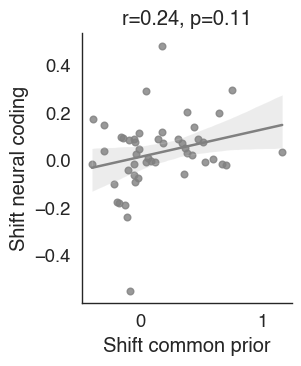

In [6]:
sns.set_theme('paper', 'white', font='helvetica', font_scale=1.5, palette='tab10')

cor = pingouin.corr(df['prior_shift'], df['E_dif'], method='shepherd')
r_, p = np.round(cor['r'].values[0], 2), np.round(cor['p-val'].values[0], 3)

plt.figure(figsize=(2.7, 3.5))
ax = sns.regplot(data=df.reset_index(), x='prior_shift', y='E_dif',
                 line_kws={'color': 'grey'}, scatter_kws={'color': 'grey'})
ax.set(xlabel='Shift common prior', ylabel='Shift neural coding', title=f'r={r_}, p={p}')
sns.despine()
#plt.savefig(op.join(plot_folder_path, f'shift-commonPrior-model{model_label}_E-diff_corr_robust.pdf'), bbox_inches='tight')

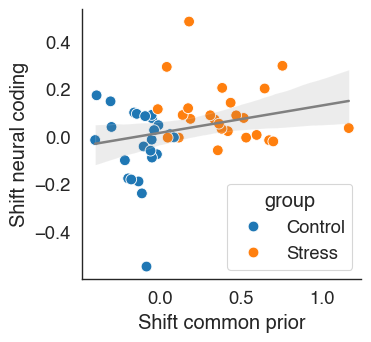

In [7]:
# same, coloured by group
plt.figure(figsize=(3.6, 3.5))
ax = sns.scatterplot(data=df.reset_index().replace({'group': {0: 'Control', 1: 'Stress'}}),
                     x='prior_shift', y='E_dif', hue='group', s=60)
sns.regplot(data=df.reset_index(), x='prior_shift', y='E_dif', scatter=False,
            line_kws={'color': 'grey'}, ax=ax)
ax.set(xlabel='Shift common prior', ylabel='Shift neural coding')
sns.despine()

## 4. Is it an individual-difference effect, or just the group difference?

Both measures differ between groups, so a raw across-subject correlation can be
produced by the group means alone. Controlling for group answers whether subjects
who shift their prior *more* also shift their neural code more.

In [8]:
print('partial correlation, controlling for group:')
print(pingouin.partial_corr(data=df.reset_index(), x='prior_shift', y='E_dif', covar='group').round(4).to_string())

print('\nwithin each group:')
for g, name in [(0, 'Control'), (1, 'Stress')]:
    t = df[df['group'] == g]
    c = pingouin.corr(t['prior_shift'], t['E_dif'])
    print(f"  {name}: n={int(c['n'].values[0])}  r={c['r'].values[0]:+.3f}  p={c['p-val'].values[0]:.4f}")

partial correlation, controlling for group:
          n       r          CI95%  p-val
pearson  49 -0.1484  [-0.42, 0.14]  0.314

within each group:
  Control: n=24  r=-0.155  p=0.4692
  Stress: n=25  r=-0.172  p=0.4116


## 5. Mediation

As in `archive/paper_fig_2.ipynb`, run in both directions.

In [9]:
dm = df.reset_index()
print('group -> prior_shift -> E_dif')
print(pingouin.mediation_analysis(data=dm, x='group', m='prior_shift', y='E_dif', n_boot=2000, seed=42).round(4).to_string(index=False))
print('\ngroup -> E_dif -> prior_shift')
print(pingouin.mediation_analysis(data=dm, x='group', m='E_dif', y='prior_shift', n_boot=2000, seed=42).round(4).to_string(index=False))

group -> prior_shift -> E_dif
           path    coef     se   pval  CI[2.5%]  CI[97.5%] sig
prior_shift ~ X  0.5210 0.0606 0.0000    0.3990     0.6429 Yes
Y ~ prior_shift  0.1151 0.0641 0.0791   -0.0139     0.2442  No
          Total  0.1305 0.0399 0.0020    0.0503     0.2107 Yes
         Direct  0.1814 0.0639 0.0067    0.0527     0.3100 Yes
       Indirect -0.0509 0.0475 0.2460   -0.1482     0.0402  No

group -> E_dif -> prior_shift
     path    coef     se   pval  CI[2.5%]  CI[97.5%] sig
E_dif ~ X  0.1305 0.0399 0.0020    0.0503     0.2107 Yes
Y ~ E_dif  0.5573 0.3105 0.0791   -0.0673     1.1819  No
    Total  0.5210 0.0606 0.0000    0.3990     0.6429 Yes
   Direct  0.5504 0.0671 0.0000    0.4153     0.6856 Yes
 Indirect -0.0295 0.0266 0.2460   -0.0873     0.0212  No


## 6. Comparison with the original model-1 (risky-prior-only) version

The number that appeared in the old figure drafts.

In [10]:
old1 = pd.read_csv(op.join(bids_folder, 'interim_sum_data', 'subwise_change_risky_prior_model-1.csv')).set_index('subject')['risky_prior_mu']
d1 = df.join(old1).dropna(subset=['risky_prior_mu', 'E_dif'])

print('model-1 risky prior shift vs E_dif:')
for method in ['pearson', 'shepherd']:
    c = pingouin.corr(d1['risky_prior_mu'], d1['E_dif'], method=method)
    print(f"  {method:9s} r={c['r'].values[0]:+.3f}  p={c['p-val'].values[0]:.4f}  n={int(c['n'].values[0])}")

print('\n  controlling for group:')
print(pingouin.partial_corr(data=d1.reset_index(), x='risky_prior_mu', y='E_dif', covar='group').round(4).to_string())

c = pingouin.corr(d1['prior_shift'], d1['risky_prior_mu'])
print(f"\nthe two shift measures agree: r={c['r'].values[0]:+.3f}, p={c['p-val'].values[0]:.3g}, n={int(c['n'].values[0])}")

model-1 risky prior shift vs E_dif:
  pearson   r=+0.362  p=0.0105  n=49
  shepherd  r=+0.375  p=0.0103  n=49

  controlling for group:
          n       r          CI95%   p-val
pearson  49 -0.0273  [-0.31, 0.26]  0.8539

the two shift measures agree: r=+0.922, p=5.4e-21, n=49


## 7. Relation to the stress manipulation (cortisol AUC)

In [11]:
auc = pd.read_csv(op.join(bids_folder, 'interim_sum_data', 'r-prior-shift_Ediff_AUC.csv')).set_index('subject')[['AUC']]
t = df.join(auc)

for y in ['prior_shift', 'E_dif']:
    tt = t.dropna(subset=['AUC', y])
    c = pingouin.corr(tt['AUC'], tt[y])
    print(f"AUC ~ {y:12s}: n={int(c['n'].values[0])}  r={c['r'].values[0]:+.3f}  p={c['p-val'].values[0]:.4f}")

AUC ~ prior_shift : n=48  r=+0.433  p=0.0021
AUC ~ E_dif       : n=48  r=+0.248  p=0.0894


## 8. Save the combined table

Model-5 counterpart of `interim_sum_data/r-prior-shift_Ediff_AUC.csv` (which holds
the model-1 risky-prior shift).

In [12]:
out = df.join(auc)
out.to_csv(op.join(bids_folder, 'interim_sum_data', f'commonPriorShift-model{model_label}_Ediff_AUC.csv'))
out.head()

,prior_shift,prior_shift_sd,E_dif,group,AUC
subject,,,,,
2,0.058431,0.323770,0.010657,0,-0.505
3,0.185066,0.236798,0.075062,1,3.530
4,0.433309,0.258464,0.143165,1,1.055
5,-0.053908,0.169397,-0.012330,0,-0.635
9,-0.301888,0.164163,0.041127,0,-1.595
